# MOAMS-X: Cross-Domain State Transplant Analysis

Live cross-lingual hidden state transplant across **math, commonsense reasoning, code generation, and logical deduction**.

Protocol: During autoregressive generation, at token T, swap the hidden state at layer L from the Chinese generation into the English generation stream. Grade output for correctness and language.

Plus **Hankel/SSA trajectory analysis**: spectral decomposition of generation dynamics across languages.

In [1]:
import json, glob
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 120
matplotlib.rcParams['font.size'] = 11

# Load all available MOAMS results
moams_files = sorted(glob.glob('output/exp_moams_x_*.json') + glob.glob('output/exp_moams_Qwen_*.json'))
hankel_files = sorted(glob.glob('output/exp_hankel_*.json'))

print(f'MOAMS files: {moams_files}')
print(f'Hankel files: {hankel_files}')

# Load cross-domain results (primary)
data_x = None
for f in moams_files:
    if 'moams_x' in f:
        data_x = json.load(open(f))
        print(f'\nLoaded cross-domain: {f}')
        print(f'  Model: {data_x["model"]}')
        print(f'  Problems: {data_x["n_problems"]}')
        print(f'  Domains: {list(data_x.get("summary", {}).keys())}')
        break

# Load original math-only MOAMS
data_math = None
for f in moams_files:
    if 'moams_x' not in f:
        data_math = json.load(open(f))
        print(f'\nLoaded math-only: {f}')
        print(f'  Model: {data_math["model"]}')
        print(f'  Results: {len(data_math["results"])} transplants')
        break

# Load Hankel
data_hankel = None
if hankel_files:
    data_hankel = json.load(open(hankel_files[0]))
    print(f'\nLoaded Hankel: {hankel_files[0]}')
    print(f'  Results: {len(data_hankel["results"])} layer-problem pairs')

# Use whichever is available
results = data_x['results'] if data_x else data_math['results']

MOAMS files: ['output/exp_moams_Qwen_Qwen3-8B.json', 'output/exp_moams_x_Qwen_Qwen3-8B_nonmath.json']
Hankel files: ['output/exp_hankel_Qwen_Qwen3-8B_nonmath.json']

Loaded cross-domain: output/exp_moams_x_Qwen_Qwen3-8B_nonmath.json
  Model: Qwen/Qwen3-8B
  Problems: 26
  Domains: ['code', 'commonsense', 'logic']

Loaded math-only: output/exp_moams_Qwen_Qwen3-8B.json
  Model: Qwen/Qwen3-8B
  Results: 180 transplants

Loaded Hankel: output/exp_hankel_Qwen_Qwen3-8B_nonmath.json
  Results: 46 layer-problem pairs


## 1. Transplant Success Rate by Domain

In [2]:
from collections import defaultdict

# Group results by domain
domain_stats = defaultdict(lambda: {'total': 0, 'tx_correct': 0, 'en_correct': 0, 'tx_english': 0})

for r in results:
    d = r.get('domain', 'math')
    domain_stats[d]['total'] += 1
    if r['tx_correct']:
        domain_stats[d]['tx_correct'] += 1
    if r['en_correct']:
        domain_stats[d]['en_correct'] += 1
    if r.get('tx_lang') == 'en':
        domain_stats[d]['tx_english'] += 1

# Display table
print(f"{'Domain':<15} {'N':>5} {'TX Correct':>12} {'Rate':>8} {'EN Output':>12} {'EN Rate':>8}")
print('-' * 65)
total_n, total_c = 0, 0
for d in sorted(domain_stats.keys()):
    s = domain_stats[d]
    rate = s['tx_correct'] / s['total'] * 100
    en_rate = s['tx_english'] / s['total'] * 100
    print(f"{d:<15} {s['total']:>5} {s['tx_correct']:>6}/{s['total']:<5} {rate:>7.0f}% {s['tx_english']:>6}/{s['total']:<5} {en_rate:>7.0f}%")
    total_n += s['total']
    total_c += s['tx_correct']
print('-' * 65)
print(f"{'TOTAL':<15} {total_n:>5} {total_c:>6}/{total_n:<5} {total_c/total_n*100:>7.0f}%")

Domain              N   TX Correct     Rate    EN Output  EN Rate
-----------------------------------------------------------------
code               32     32/32        100%     31/32         97%
commonsense        40     36/40         90%     37/40         92%
logic              32     32/32        100%     32/32        100%
-----------------------------------------------------------------
TOTAL             104    100/104        96%


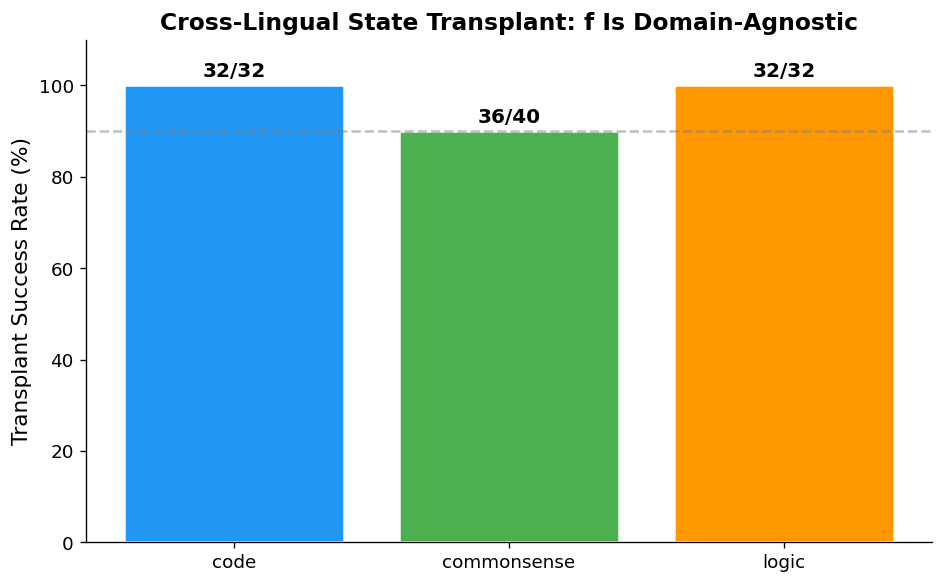

In [3]:
# Bar chart: transplant success rate by domain
domains = sorted(domain_stats.keys())
rates = [domain_stats[d]['tx_correct'] / domain_stats[d]['total'] * 100 for d in domains]
colors = {'code': '#2196F3', 'commonsense': '#4CAF50', 'logic': '#FF9800', 'math': '#9C27B0'}
bar_colors = [colors.get(d, '#666') for d in domains]

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(domains, rates, color=bar_colors, edgecolor='white', linewidth=1.5)

# Add value labels
for bar, d in zip(bars, domains):
    s = domain_stats[d]
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f"{s['tx_correct']}/{s['total']}",
            ha='center', va='bottom', fontweight='bold', fontsize=12)

ax.set_ylim(0, 110)
ax.set_ylabel('Transplant Success Rate (%)', fontsize=13)
ax.set_title('Cross-Lingual State Transplant: f Is Domain-Agnostic', fontsize=14, fontweight='bold')
ax.axhline(y=90, color='gray', linestyle='--', alpha=0.5, label='90% threshold')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('output/fig_moams_x_domain_rates.png', dpi=200, bbox_inches='tight')
plt.show()

## 2. Transplant Success by Layer and Token

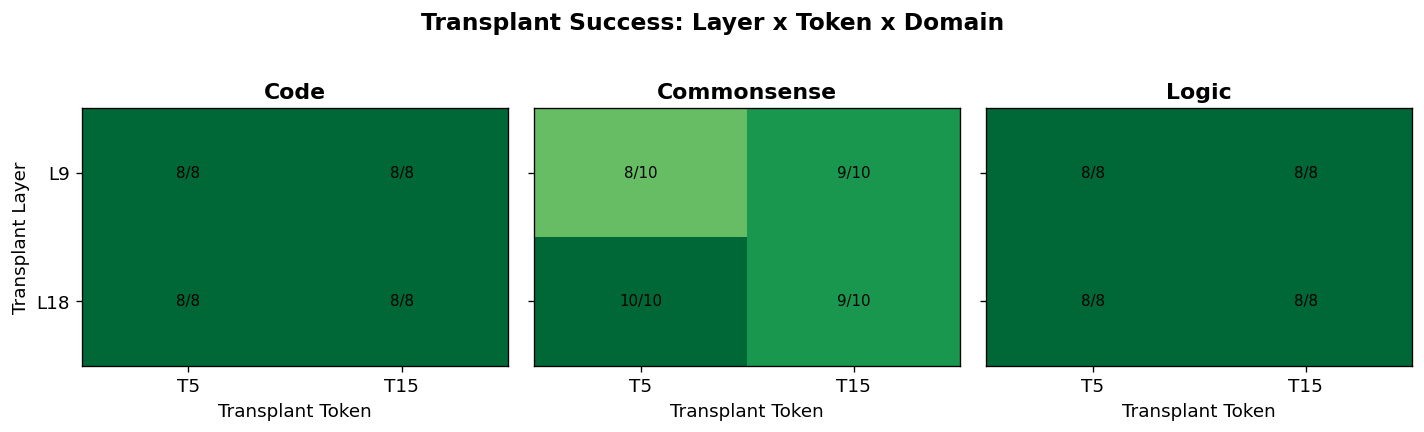

In [4]:
# Heatmap: success rate by (layer, token) for each domain
layers = sorted(set(r['transplant_layer'] for r in results))
tokens = sorted(set(r['transplant_token'] for r in results))
domains = sorted(set(r.get('domain', 'math') for r in results))

n_domains = len(domains)
fig, axes = plt.subplots(1, n_domains, figsize=(4 * n_domains, 3.5), sharey=True)
if n_domains == 1:
    axes = [axes]

for ax, domain in zip(axes, domains):
    grid = np.zeros((len(layers), len(tokens)))
    counts = np.zeros((len(layers), len(tokens)))
    
    for r in results:
        if r.get('domain', 'math') != domain:
            continue
        li = layers.index(r['transplant_layer'])
        ti = tokens.index(r['transplant_token'])
        counts[li, ti] += 1
        if r['tx_correct']:
            grid[li, ti] += 1
    
    # Convert to rates
    rate_grid = np.where(counts > 0, grid / counts * 100, 0)
    
    im = ax.imshow(rate_grid, cmap='RdYlGn', vmin=0, vmax=100, aspect='auto')
    ax.set_xticks(range(len(tokens)))
    ax.set_xticklabels([f'T{t}' for t in tokens])
    ax.set_yticks(range(len(layers)))
    ax.set_yticklabels([f'L{l}' for l in layers])
    ax.set_title(domain.capitalize(), fontweight='bold')
    ax.set_xlabel('Transplant Token')
    if ax == axes[0]:
        ax.set_ylabel('Transplant Layer')
    
    # Annotate cells
    for i in range(len(layers)):
        for j in range(len(tokens)):
            if counts[i, j] > 0:
                ax.text(j, i, f'{int(grid[i,j])}/{int(counts[i,j])}',
                        ha='center', va='center', fontsize=9,
                        color='white' if rate_grid[i,j] < 50 else 'black')

fig.suptitle('Transplant Success: Layer x Token x Domain', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('output/fig_moams_x_heatmap.png', dpi=200, bbox_inches='tight')
plt.show()

## 3. Cosine Similarity at Transplant Point

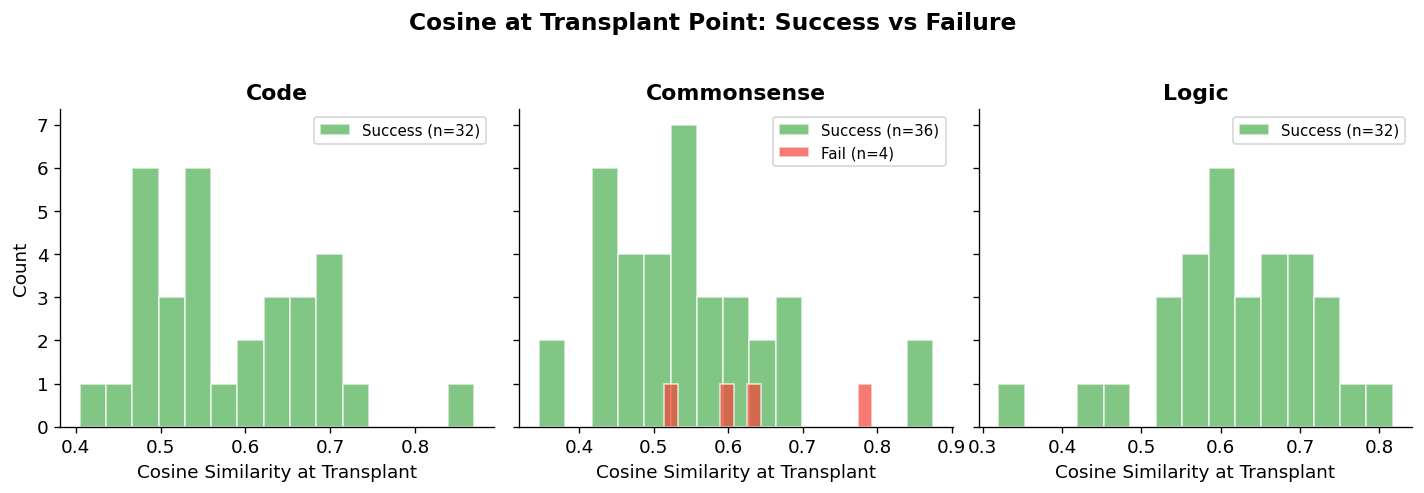

In [5]:
# Distribution of cosine similarity at transplant point, colored by success/failure
fig, axes = plt.subplots(1, n_domains, figsize=(4 * n_domains, 4), sharey=True)
if n_domains == 1:
    axes = [axes]

for ax, domain in zip(axes, domains):
    subset = [r for r in results if r.get('domain', 'math') == domain]
    
    cos_success = [r['cosine_at_transplant'] for r in subset 
                   if r['tx_correct'] and r['cosine_at_transplant'] is not None]
    cos_fail = [r['cosine_at_transplant'] for r in subset 
                if not r['tx_correct'] and r['cosine_at_transplant'] is not None]
    
    if cos_success:
        ax.hist(cos_success, bins=15, alpha=0.7, color='#4CAF50', label=f'Success (n={len(cos_success)})', edgecolor='white')
    if cos_fail:
        ax.hist(cos_fail, bins=15, alpha=0.7, color='#F44336', label=f'Fail (n={len(cos_fail)})', edgecolor='white')
    
    ax.set_xlabel('Cosine Similarity at Transplant')
    ax.set_title(domain.capitalize(), fontweight='bold')
    ax.legend(fontsize=9)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

axes[0].set_ylabel('Count')
fig.suptitle('Cosine at Transplant Point: Success vs Failure', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('output/fig_moams_x_cosine_dist.png', dpi=200, bbox_inches='tight')
plt.show()

## 4. Hankel/SSA Trajectory Analysis

In [6]:
if data_hankel is None:
    print('No Hankel data available yet. Will populate when results download.')
else:
    h_results = data_hankel['results']
    h_domains = sorted(set(r['domain'] for r in h_results))
    h_layers = sorted(set(r['layer'] for r in h_results))
    
    print(f'Hankel results: {len(h_results)} entries across {h_domains}')
    print(f'Layers: {h_layers}')
    
    # Table: mean spectral correlation and subspace overlap by domain x layer
    print(f"\n{'Domain':<15} {'Layer':>6} {'Spec.Corr':>12} {'Subspace':>12} {'Raw Cos':>12}")
    print('-' * 60)
    for domain in h_domains:
        for layer in h_layers:
            sub = [r for r in h_results if r['domain'] == domain and r['layer'] == layer]
            if not sub:
                continue
            sc = np.mean([r['spectral_correlation'] for r in sub if r['spectral_correlation'] is not None])
            so = np.mean([r['subspace_overlap'] for r in sub if r['subspace_overlap'] is not None])
            rc = np.mean([r['raw_cosine_mean'] for r in sub])
            print(f"{domain:<15} {layer:>6} {sc:>12.4f} {so:>12.4f} {rc:>12.4f}")

Hankel results: 46 entries across ['code', 'commonsense', 'logic']
Layers: [9, 18]

Domain           Layer    Spec.Corr     Subspace      Raw Cos
------------------------------------------------------------
code                 9       0.9807       0.4120       0.5776
code                18       0.9478       0.2419       0.5413
commonsense          9       0.9623       0.4555       0.5304
commonsense         18       0.9717       0.5507       0.6138
logic                9       0.9610       0.2943       0.6035
logic               18       0.9661       0.3339       0.6417


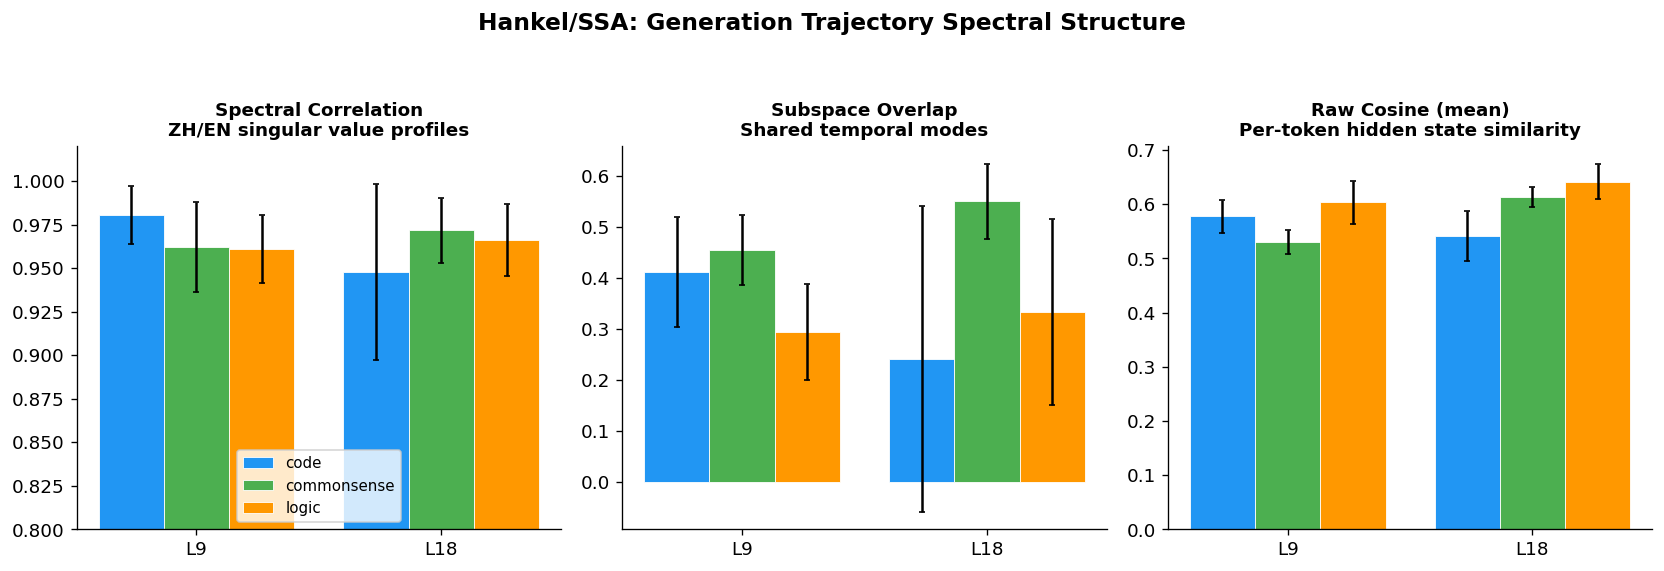

In [7]:
if data_hankel is not None:
    h_results = data_hankel['results']
    h_domains = sorted(set(r['domain'] for r in h_results))
    h_layers = sorted(set(r['layer'] for r in h_results))
    
    fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))
    metrics = [
        ('spectral_correlation', 'Spectral Correlation', 'ZH/EN singular value profiles'),
        ('subspace_overlap', 'Subspace Overlap', 'Shared temporal modes'),
        ('raw_cosine_mean', 'Raw Cosine (mean)', 'Per-token hidden state similarity'),
    ]
    
    for ax, (key, title, subtitle) in zip(axes, metrics):
        x = np.arange(len(h_layers))
        width = 0.8 / len(h_domains)
        
        for di, domain in enumerate(h_domains):
            vals = []
            errs = []
            for layer in h_layers:
                sub = [r[key] for r in h_results 
                       if r['domain'] == domain and r['layer'] == layer and r[key] is not None]
                vals.append(np.mean(sub) if sub else 0)
                errs.append(np.std(sub) if len(sub) > 1 else 0)
            
            offset = (di - len(h_domains)/2 + 0.5) * width
            ax.bar(x + offset, vals, width, yerr=errs, 
                   label=domain, color=colors.get(domain, '#666'),
                   edgecolor='white', linewidth=0.5, capsize=2)
        
        ax.set_xticks(x)
        ax.set_xticklabels([f'L{l}' for l in h_layers])
        ax.set_title(f'{title}\n{subtitle}', fontsize=11, fontweight='bold')
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        if key == 'spectral_correlation':
            ax.set_ylim(0.8, 1.02)
            ax.legend(fontsize=9)
    
    fig.suptitle('Hankel/SSA: Generation Trajectory Spectral Structure', fontsize=14, fontweight='bold', y=1.05)
    plt.tight_layout()
    plt.savefig('output/fig_hankel_ssa.png', dpi=200, bbox_inches='tight')
    plt.show()
else:
    print('Hankel data not yet available.')

## 5. Per-Problem Detail View

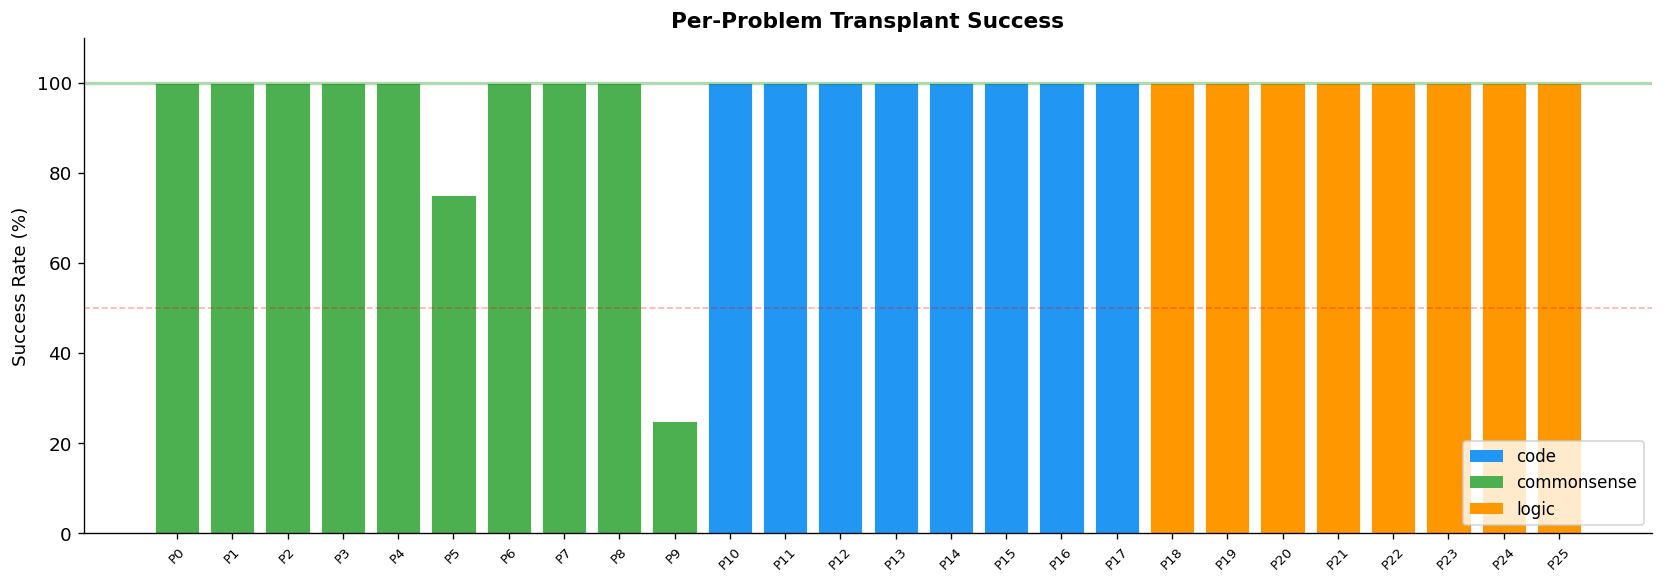


Problem index reference:
  P0 [commonsense]: If you put a lit candle inside a sealed ... -> 100%
  P1 [commonsense]: You leave a glass of ice water on a tabl... -> 100%
  P2 [commonsense]: Why does a metal spoon feel colder than ... -> 100%
  P3 [commonsense]: A ship made of steel floats, but a solid... -> 100%
  P4 [commonsense]: If you are in an elevator and the cable ... -> 100%
  P5 [commonsense]: Why do hospitals use white coats for doc... -> 75%
  P6 [commonsense]: Why is it harder to stop a large truck t... -> 100%
  P7 [commonsense]: A person is stranded in a desert with a ... -> 100%
  P8 [commonsense]: Why does spinning a raw egg and a hard-b... -> 100%
  P9 [commonsense]: You are on a boat in a lake, holding a l... -> 25%
  P10 [code]: Write a Python function called binary_se... -> 100%
  P11 [code]: Write a Python function called is_palind... -> 100%
  P12 [code]: Write a Python function called merge_sor... -> 100%
  P13 [code]: Write a Python function called lcs that ... 

In [8]:
# Per-problem success rate with domain coloring
problem_indices = sorted(set(r['problem_idx'] for r in results))
prob_domains = {}
prob_rates = {}
prob_labels = {}

for pi in problem_indices:
    sub = [r for r in results if r['problem_idx'] == pi]
    if not sub:
        continue
    n = len(sub)
    c = sum(1 for r in sub if r['tx_correct'])
    prob_rates[pi] = c / n * 100
    prob_domains[pi] = sub[0].get('domain', 'math')
    prob_labels[pi] = sub[0]['problem'][:40] + '...'

fig, ax = plt.subplots(figsize=(14, 5))
x_vals = list(range(len(problem_indices)))
bar_colors_prob = [colors.get(prob_domains[pi], '#666') for pi in problem_indices]
rates_list = [prob_rates[pi] for pi in problem_indices]

bars = ax.bar(x_vals, rates_list, color=bar_colors_prob, edgecolor='white', linewidth=0.5)
ax.set_xticks(x_vals)
ax.set_xticklabels([f'P{pi}' for pi in problem_indices], fontsize=8, rotation=45)
ax.set_ylabel('Success Rate (%)')
ax.set_ylim(0, 110)
ax.axhline(y=100, color='green', alpha=0.3, linewidth=2)
ax.axhline(y=50, color='red', alpha=0.3, linewidth=1, linestyle='--')
ax.set_title('Per-Problem Transplant Success', fontsize=13, fontweight='bold')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Domain legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=colors[d], label=d) for d in sorted(colors.keys()) if d in prob_domains.values()]
ax.legend(handles=legend_elements, loc='lower right', fontsize=10)

plt.tight_layout()
plt.savefig('output/fig_moams_x_per_problem.png', dpi=200, bbox_inches='tight')
plt.show()

# Print the problem names for reference
print('\nProblem index reference:')
for pi in problem_indices:
    print(f'  P{pi} [{prob_domains[pi]}]: {prob_labels[pi]} -> {prob_rates[pi]:.0f}%')

## 6. Language Switch Analysis

Some transplants switch the output language (EN prompt produces ZH output after ZH state injection). This is not a failure — the reasoning content is still correct. It shows the transplanted state carries language identity.

In [9]:
# Language switch analysis
lang_stats = defaultdict(lambda: {'total': 0, 'switched': 0, 'correct_when_switched': 0})

for r in results:
    d = r.get('domain', 'math')
    lang_stats[d]['total'] += 1
    if r.get('tx_lang') == 'zh':  # Output switched to Chinese
        lang_stats[d]['switched'] += 1
        if r['tx_correct']:
            lang_stats[d]['correct_when_switched'] += 1

print(f"{'Domain':<15} {'Total':>6} {'Switched':>10} {'Correct/Switch':>16}")
print('-' * 50)
for d in sorted(lang_stats.keys()):
    s = lang_stats[d]
    sw_rate = s['switched'] / s['total'] * 100 if s['total'] else 0
    c_rate = s['correct_when_switched'] / s['switched'] * 100 if s['switched'] else 0
    print(f"{d:<15} {s['total']:>6} {s['switched']:>5} ({sw_rate:.0f}%) {s['correct_when_switched']:>5}/{s['switched']:<3} ({c_rate:.0f}%)")

print('\nKey: "Switched" means EN prompt produced ZH output after ZH state transplant.')
print('"Correct/Switch" = reasoning content correct despite wrong output language.')

Domain           Total   Switched   Correct/Switch
--------------------------------------------------
code                32     1 (3%)     1/1   (100%)
commonsense         40     3 (8%)     3/3   (100%)
logic               32     0 (0%)     0/0   (0%)

Key: "Switched" means EN prompt produced ZH output after ZH state transplant.
"Correct/Switch" = reasoning content correct despite wrong output language.


## 7. Summary Statistics

In [10]:
# Grand summary
total = len(results)
correct = sum(1 for r in results if r['tx_correct'])
english = sum(1 for r in results if r.get('tx_lang') == 'en')
cos_vals = [r['cosine_at_transplant'] for r in results if r['cosine_at_transplant'] is not None]

print('=' * 60)
print('MOAMS-X GRAND SUMMARY')
print('=' * 60)
print(f'Total transplants:      {total}')
print(f'Correct:                {correct}/{total} ({correct/total*100:.1f}%)')
print(f'Output in English:      {english}/{total} ({english/total*100:.1f}%)')
print(f'Mean cosine at tx:      {np.mean(cos_vals):.4f} +/- {np.std(cos_vals):.4f}')
print()
print('By domain:')
for d in sorted(domain_stats.keys()):
    s = domain_stats[d]
    rate = s['tx_correct'] / s['total'] * 100
    print(f'  {d:<15} {s["tx_correct"]:>3}/{s["total"]} ({rate:.0f}%)')

if data_hankel:
    h_sc = [r['spectral_correlation'] for r in data_hankel['results'] if r['spectral_correlation'] is not None]
    h_so = [r['subspace_overlap'] for r in data_hankel['results'] if r['subspace_overlap'] is not None]
    print(f'\nHankel/SSA:')
    print(f'  Mean spectral corr:   {np.mean(h_sc):.4f} +/- {np.std(h_sc):.4f}')
    print(f'  Mean subspace overlap: {np.mean(h_so):.4f} +/- {np.std(h_so):.4f}')

MOAMS-X GRAND SUMMARY
Total transplants:      104
Correct:                100/104 (96.2%)
Output in English:      100/104 (96.2%)
Mean cosine at tx:      0.5838 +/- 0.1086

By domain:
  code             32/32 (100%)
  commonsense      36/40 (90%)
  logic            32/32 (100%)

Hankel/SSA:
  Mean spectral corr:   0.9653 +/- 0.0302
  Mean subspace overlap: 0.4007 +/- 0.1903


## 8. Per-Token Trajectory Analysis (Qwen2.5-3B)

Load the per-token hidden state trajectories captured at all 36 layers during generation.
These show how the ZH and EN hidden states evolve token-by-token — the temporal dynamics of f.

In [11]:
# Load trajectory data
import os
traj_files = sorted(glob.glob('output/trajectories_*.json'))
print(f'Trajectory files: {traj_files}')

traj_data = None
for f in traj_files:
    traj_data = json.load(open(f))
    print(f'\nLoaded: {f}')
    print(f'  Model: {traj_data["model"]}')
    print(f'  Layers recorded: {len(traj_data["layers_recorded"])}')
    print(f'  Problems: {traj_data["n_problems"]}')
    for r in traj_data['results'][:3]:
        print(f'    P{r["problem_idx"]} [{r["domain"]}]: ZH={r["zh_ntok"]}tok EN={r["en_ntok"]}tok')
    break

if traj_data is None:
    print('No trajectory data found. Run perturbation/exp_trajectory_capture.py first.')

DC = {'math': '#9C27B0', 'commonsense': '#4CAF50', 'code': '#2196F3', 'logic': '#FF9800'}
traj_results = traj_data['results'] if traj_data else []
traj_n_layers = traj_data['n_layers'] if traj_data else 36

Trajectory files: ['output/trajectories_Qwen_Qwen2.5-3B_all.json']

Loaded: output/trajectories_Qwen_Qwen2.5-3B_all.json
  Model: Qwen/Qwen2.5-3B
  Layers recorded: 36
  Problems: 16
    P0 [math]: ZH=15tok EN=208tok
    P1 [math]: ZH=14tok EN=375tok
    P2 [math]: ZH=183tok EN=270tok


### 8a. Cosine Heatmaps: Layer × Token per Problem
Each panel = one problem. X = normalized time [0,1]. Y = layer. Color = cos(ZH, EN).
Green = high alignment, red = divergent. Watch for the convergence zone (L12+) and the L35 crash.

/tmp/ipykernel_4087493/1337894614.py:44: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.91, 0.98])


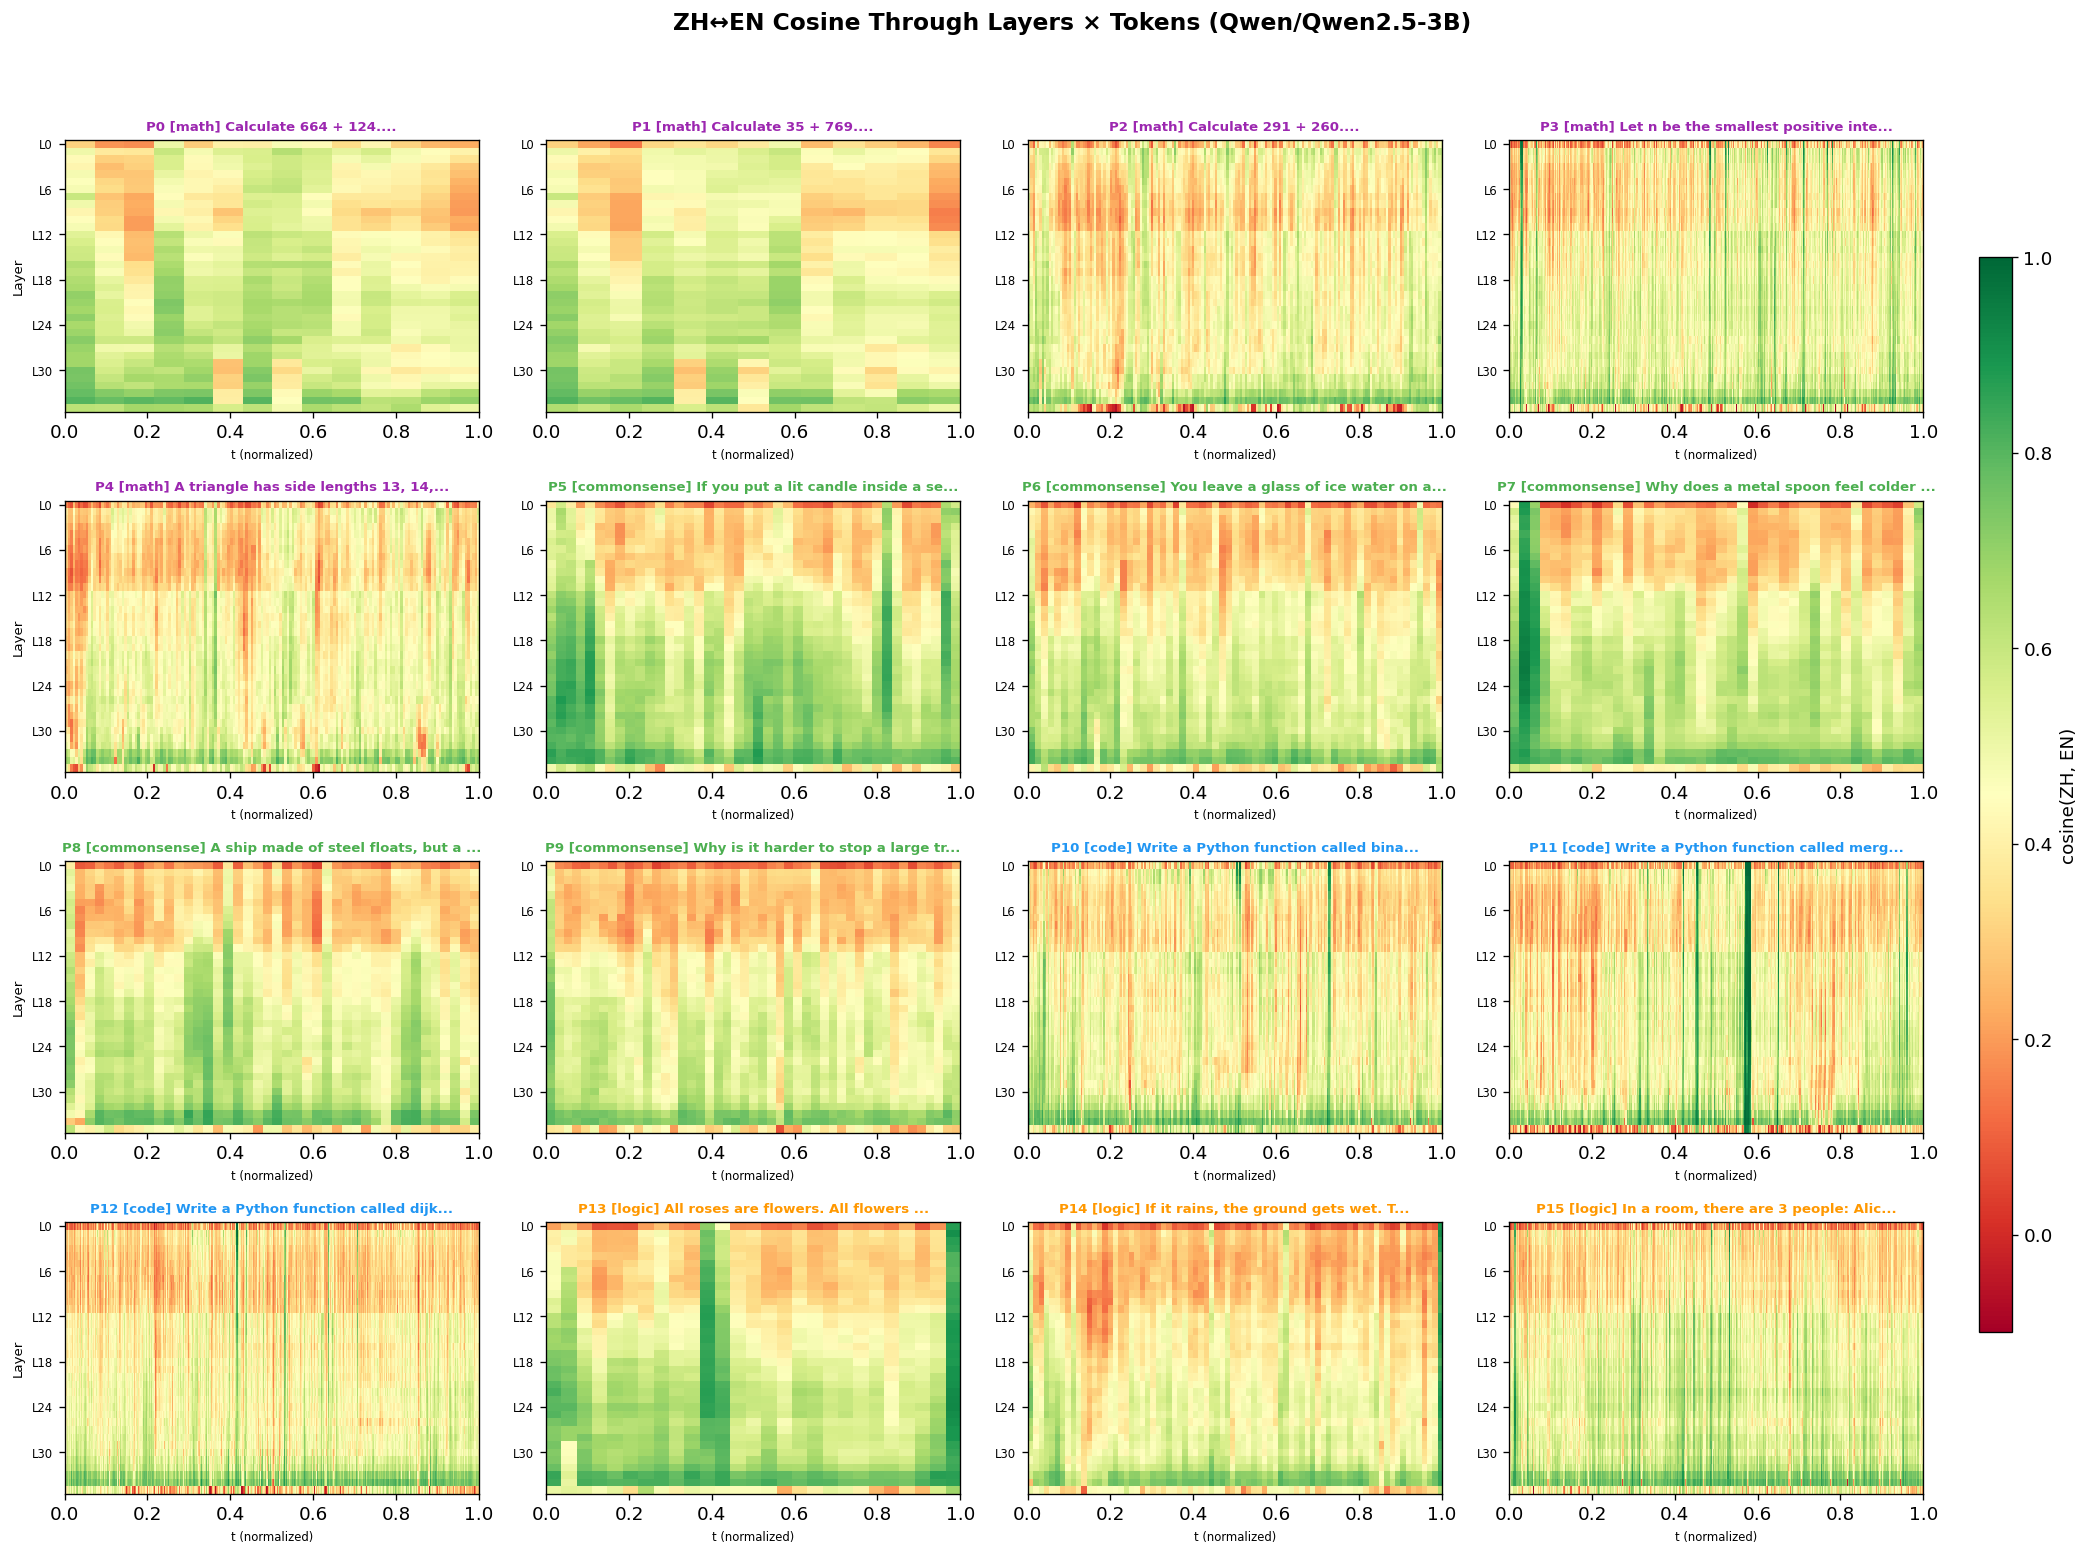

In [12]:
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable

n_problems = len(traj_results)
n_cols = 4
n_rows = (n_problems + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 3.2 * n_rows), squeeze=False)

for idx, r in enumerate(traj_results):
    ax = axes[idx // n_cols][idx % n_cols]
    domain = r["domain"]
    pi = r["problem_idx"]
    all_layers = sorted(int(k) for k in r["layers"].keys())
    cos_data = r["layers"]
    max_t = max(len(cos_data[str(li)]["cosines"]) for li in all_layers)
    if max_t == 0:
        ax.set_title(f"P{pi} [{domain}] NO DATA", fontsize=9)
        continue

    heatmap = np.full((len(all_layers), max_t), np.nan)
    for yi, li in enumerate(all_layers):
        cos = cos_data[str(li)]["cosines"]
        heatmap[yi, :len(cos)] = cos

    im = ax.imshow(heatmap, aspect="auto", cmap="RdYlGn", vmin=-0.1, vmax=1.0,
                   extent=[0, 1, len(all_layers) - 0.5, -0.5], interpolation="nearest")
    tick_positions = list(range(0, len(all_layers), 6))
    ax.set_yticks(tick_positions)
    ax.set_yticklabels([f"L{all_layers[i]}" for i in tick_positions], fontsize=7)
    title_color = DC.get(domain, "black")
    short_prob = r["problem_en"][:35] + "..."
    ax.set_title(f"P{pi} [{domain}] {short_prob}", fontsize=8, color=title_color, fontweight="bold")
    ax.set_xlabel("t (normalized)", fontsize=7)
    if idx % n_cols == 0:
        ax.set_ylabel("Layer", fontsize=8)

for idx in range(n_problems, n_rows * n_cols):
    axes[idx // n_cols][idx % n_cols].set_visible(False)

fig.suptitle(f"ZH↔EN Cosine Through Layers × Tokens ({traj_data['model']})", fontsize=14, fontweight="bold", y=1.01)
cbar_ax = fig.add_axes([0.92, 0.15, 0.015, 0.7])
fig.colorbar(ScalarMappable(norm=Normalize(-0.1, 1.0), cmap="RdYlGn"), cax=cbar_ax, label="cosine(ZH, EN)")
plt.tight_layout(rect=[0, 0, 0.91, 0.98])
plt.savefig("output/fig_cosine_heatmaps.png", dpi=200, bbox_inches="tight")
plt.show()

### 8b. Convergence Profile by Domain
Mean cosine across all tokens, by layer — one curve per domain. This is the generation-time convergence profile.
Compare: all domains follow the same shape (ramp → peak → L35 crash), but at different absolute levels.

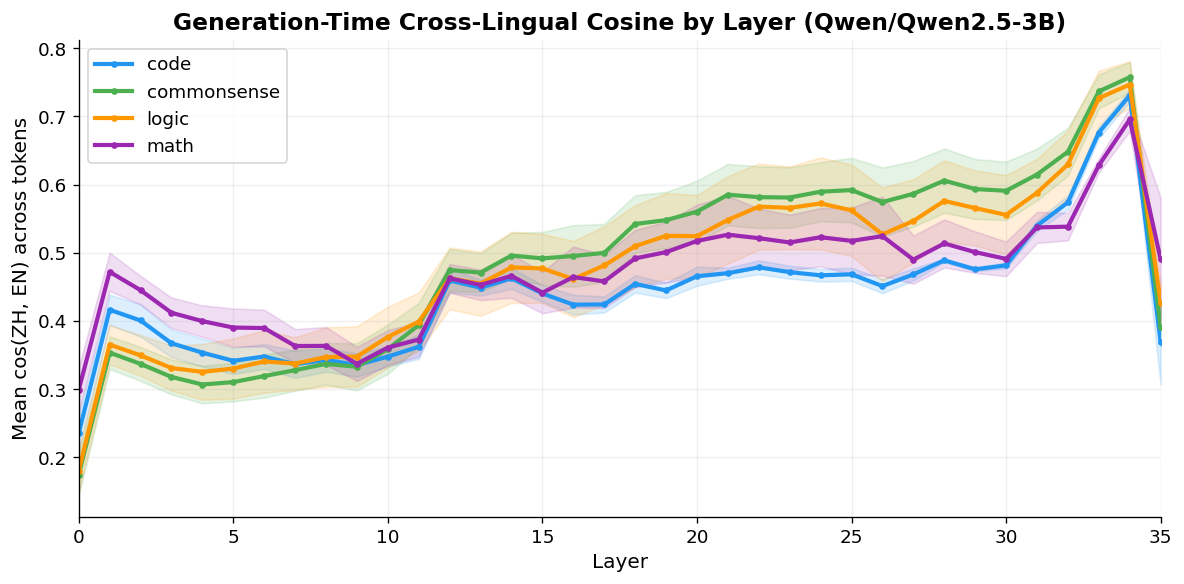

In [13]:
fig, ax = plt.subplots(figsize=(10, 5))

domains_traj = sorted(set(r["domain"] for r in traj_results))
all_layers_sorted = sorted(int(k) for k in traj_results[0]["layers"].keys())

for domain in domains_traj:
    domain_results = [r for r in traj_results if r["domain"] == domain]
    layer_means, layer_stds = [], []
    for li in all_layers_sorted:
        all_cos = []
        for r in domain_results:
            cos = r["layers"].get(str(li), {}).get("cosines", [])
            if cos:
                all_cos.append(np.mean(cos))
        layer_means.append(np.mean(all_cos) if all_cos else 0)
        layer_stds.append(np.std(all_cos) if len(all_cos) > 1 else 0)
    layer_means = np.array(layer_means)
    layer_stds = np.array(layer_stds)
    ax.plot(all_layers_sorted, layer_means, color=DC[domain], linewidth=2.5, label=domain, marker="o", markersize=3)
    ax.fill_between(all_layers_sorted, layer_means - layer_stds, layer_means + layer_stds,
                    color=DC[domain], alpha=0.15)

ax.set_xlabel("Layer", fontsize=12)
ax.set_ylabel("Mean cos(ZH, EN) across tokens", fontsize=12)
ax.set_title(f"Generation-Time Cross-Lingual Cosine by Layer ({traj_data['model']})", fontsize=14, fontweight="bold")
ax.legend(fontsize=11)
ax.grid(True, alpha=0.2)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.set_xlim(0, traj_n_layers - 1)
plt.tight_layout()
plt.savefig("output/fig_convergence_by_domain.png", dpi=200, bbox_inches="tight")
plt.show()

### 8c. Cosine Velocity — d(cos)/dt
Where is cross-lingual convergence accelerating vs decelerating? Positive = converging, negative = diverging.
Smoothed with window=5 before differencing. Like momentum on a price chart.

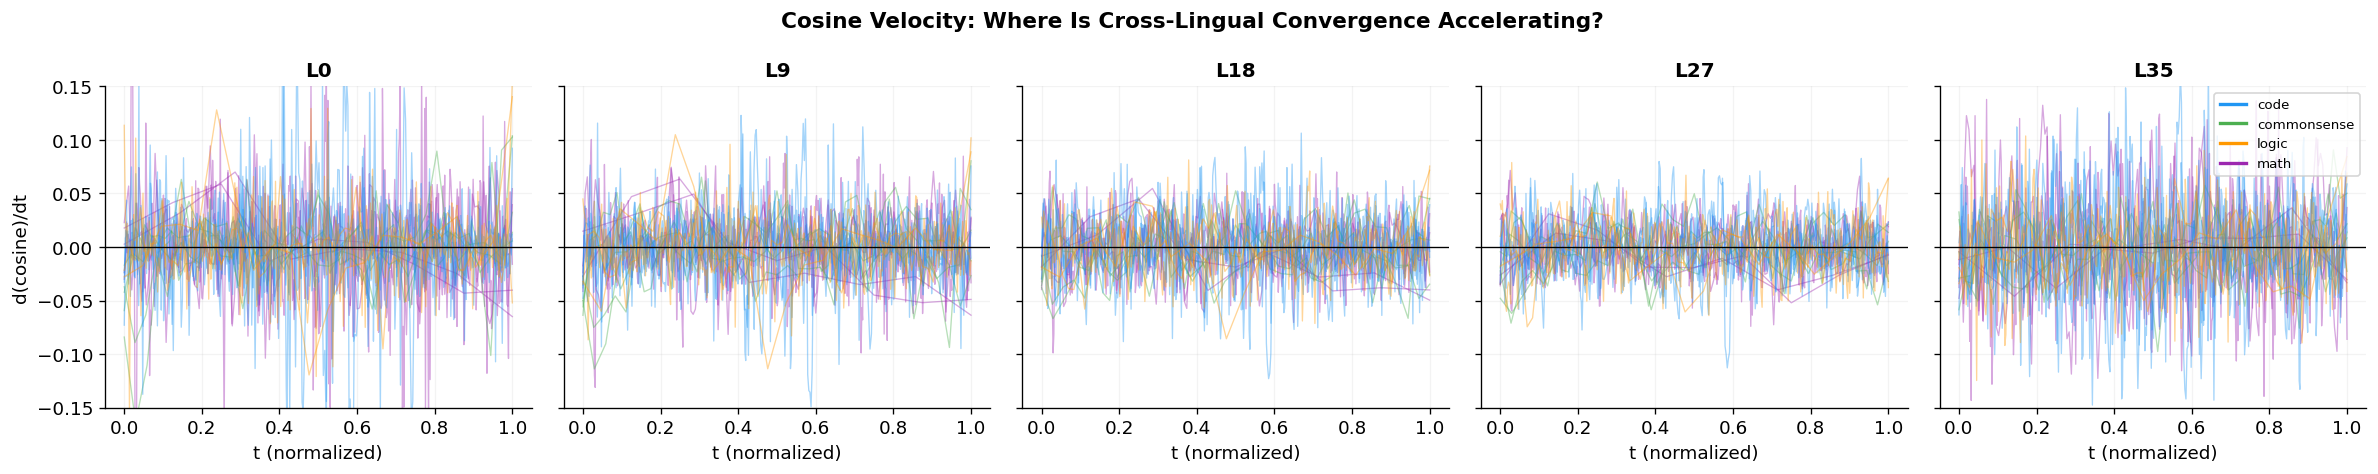

In [14]:
from matplotlib.lines import Line2D

key_layers = [l for l in [0, 9, 18, 27, 35] if l < traj_n_layers]
fig, axes = plt.subplots(1, len(key_layers), figsize=(4 * len(key_layers), 4), sharey=True)

for ax, li in zip(axes, key_layers):
    for r in traj_results:
        cos = np.array(r["layers"].get(str(li), {}).get("cosines", []))
        if len(cos) < 5:
            continue
        kernel = np.ones(5) / 5
        cos_smooth = np.convolve(cos, kernel, mode="valid")
        velocity = np.diff(cos_smooth)
        t_norm = np.linspace(0, 1, len(velocity))
        ax.plot(t_norm, velocity, color=DC.get(r["domain"], "gray"), alpha=0.4, linewidth=0.8)
    ax.axhline(0, color="black", linewidth=0.8)
    ax.set_title(f"L{li}", fontsize=12, fontweight="bold")
    ax.set_xlabel("t (normalized)")
    ax.set_ylim(-0.15, 0.15)
    ax.grid(True, alpha=0.15)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

axes[0].set_ylabel("d(cosine)/dt")
fig.suptitle("Cosine Velocity: Where Is Cross-Lingual Convergence Accelerating?", fontsize=13, fontweight="bold")
legend_elements = [Line2D([0], [0], color=DC[d], linewidth=2, label=d) for d in sorted(DC.keys())]
axes[-1].legend(handles=legend_elements, loc="upper right", fontsize=8)
plt.tight_layout()
plt.savefig("output/fig_cosine_velocity.png", dpi=200, bbox_inches="tight")
plt.show()

### 8d. Cosine Volatility — Rolling σ(cos)
Realized volatility of the cosine trajectory. High vol = unstable alignment. Low vol = locked in.
Like realized vol on a price series. Window = 10 tokens.

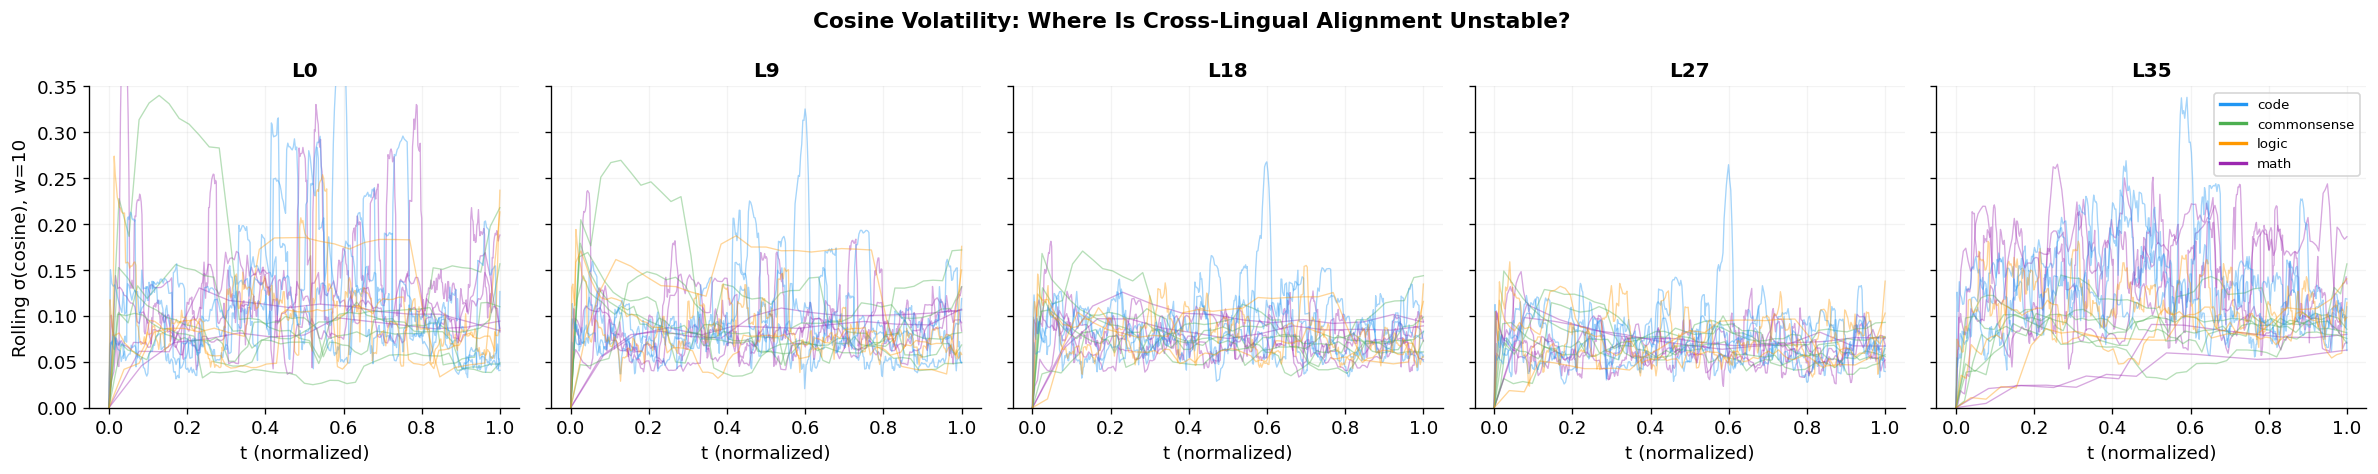

In [15]:
window = 10
fig, axes = plt.subplots(1, len(key_layers), figsize=(4 * len(key_layers), 4), sharey=True)

for ax, li in zip(axes, key_layers):
    for r in traj_results:
        cos = np.array(r["layers"].get(str(li), {}).get("cosines", []))
        if len(cos) < window + 2:
            continue
        vol = np.array([np.std(cos[max(0, i - window):i + 1]) for i in range(len(cos))])
        t_norm = np.linspace(0, 1, len(vol))
        ax.plot(t_norm, vol, color=DC.get(r["domain"], "gray"), alpha=0.4, linewidth=0.8)
    ax.set_title(f"L{li}", fontsize=12, fontweight="bold")
    ax.set_xlabel("t (normalized)")
    ax.set_ylim(0, 0.35)
    ax.grid(True, alpha=0.15)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

axes[0].set_ylabel(f"Rolling σ(cosine), w={window}")
fig.suptitle("Cosine Volatility: Where Is Cross-Lingual Alignment Unstable?", fontsize=13, fontweight="bold")
legend_elements = [Line2D([0], [0], color=DC[d], linewidth=2, label=d) for d in sorted(DC.keys())]
axes[-1].legend(handles=legend_elements, loc="upper right", fontsize=8)
plt.tight_layout()
plt.savefig("output/fig_cosine_volatility.png", dpi=200, bbox_inches="tight")
plt.show()

### 8e. Norm Ratio ZH/EN Through Layers
Which language "works harder" at each layer? Ratio > 1 = ZH norms larger (more energy).
Code stays flat ~1.0 (both languages compute at same intensity for Python output).
Math diverges at L35 — the output layer re-dressing cost is asymmetric.

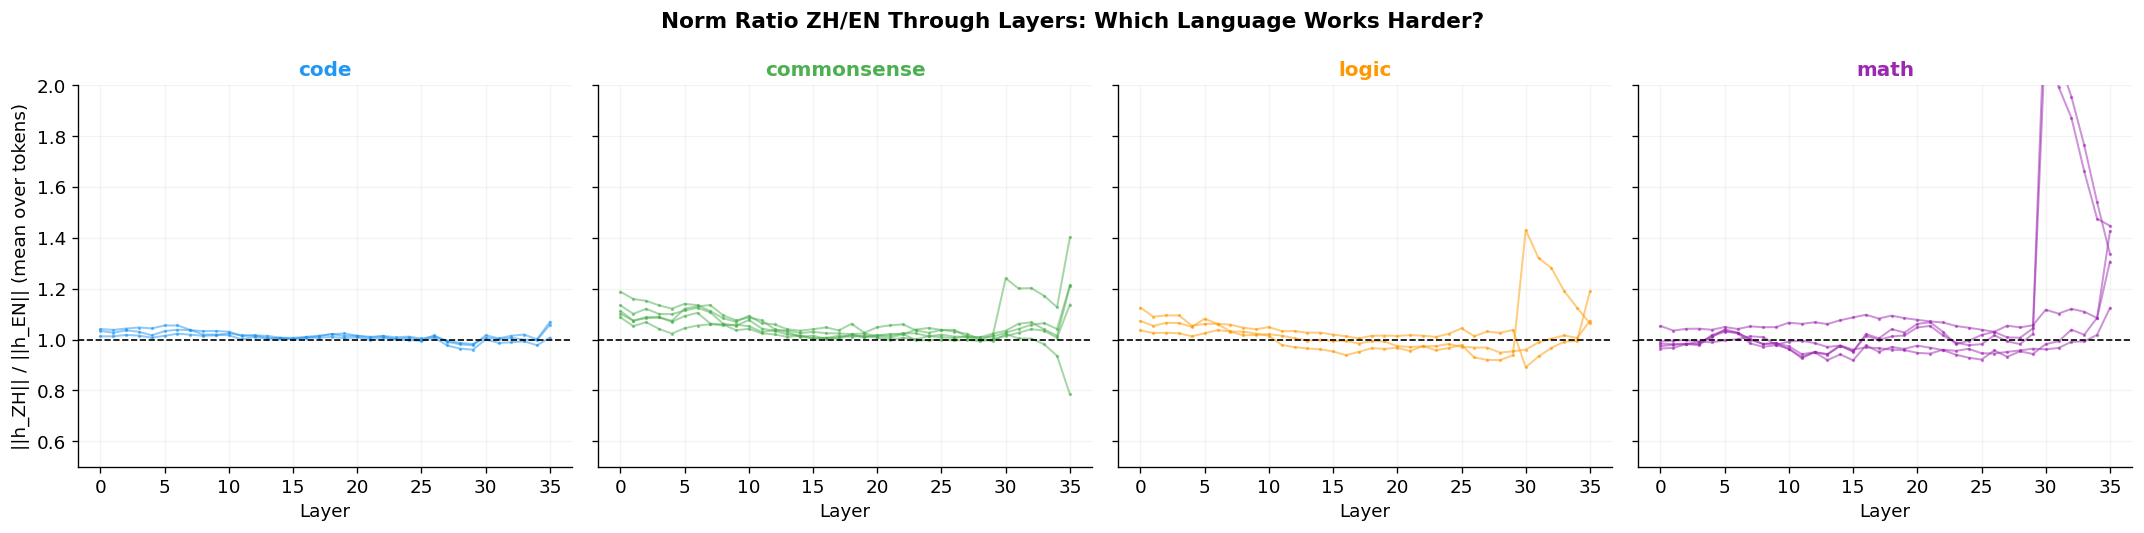

In [16]:
fig, axes = plt.subplots(1, len(domains_traj), figsize=(4.5 * len(domains_traj), 4.5), sharey=True)

for ax, domain in zip(axes, domains_traj):
    domain_results = [r for r in traj_results if r["domain"] == domain]
    for r in domain_results:
        ratios = []
        for li in all_layers_sorted:
            zh_n = r["layers"][str(li)]["zh_norms"]
            en_n = r["layers"][str(li)]["en_norms"]
            if zh_n and en_n:
                mean_zh = np.mean(zh_n)
                mean_en = np.mean(en_n)
                ratios.append(mean_zh / mean_en if mean_en > 0 else 1.0)
            else:
                ratios.append(1.0)
        ax.plot(all_layers_sorted, ratios, color=DC[domain], alpha=0.5, linewidth=1.2, marker=".", markersize=2)

    ax.axhline(1.0, color="black", linewidth=1, linestyle="--")
    ax.set_title(domain, fontsize=12, fontweight="bold", color=DC[domain])
    ax.set_xlabel("Layer")
    ax.grid(True, alpha=0.15)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.set_ylim(0.5, 2.0)

axes[0].set_ylabel("||h_ZH|| / ||h_EN|| (mean over tokens)")
fig.suptitle("Norm Ratio ZH/EN Through Layers: Which Language Works Harder?", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("output/fig_norm_ratio.png", dpi=200, bbox_inches="tight")
plt.show()

### 8f. Layer-to-Layer Cosine Jump
Where does convergence actually happen in the layer stack? Blue = convergence (cos increases between layers), red = divergence.
Shows which layer transitions contribute most to cross-lingual alignment, and when during generation.

/tmp/ipykernel_4087493/317654418.py:31: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


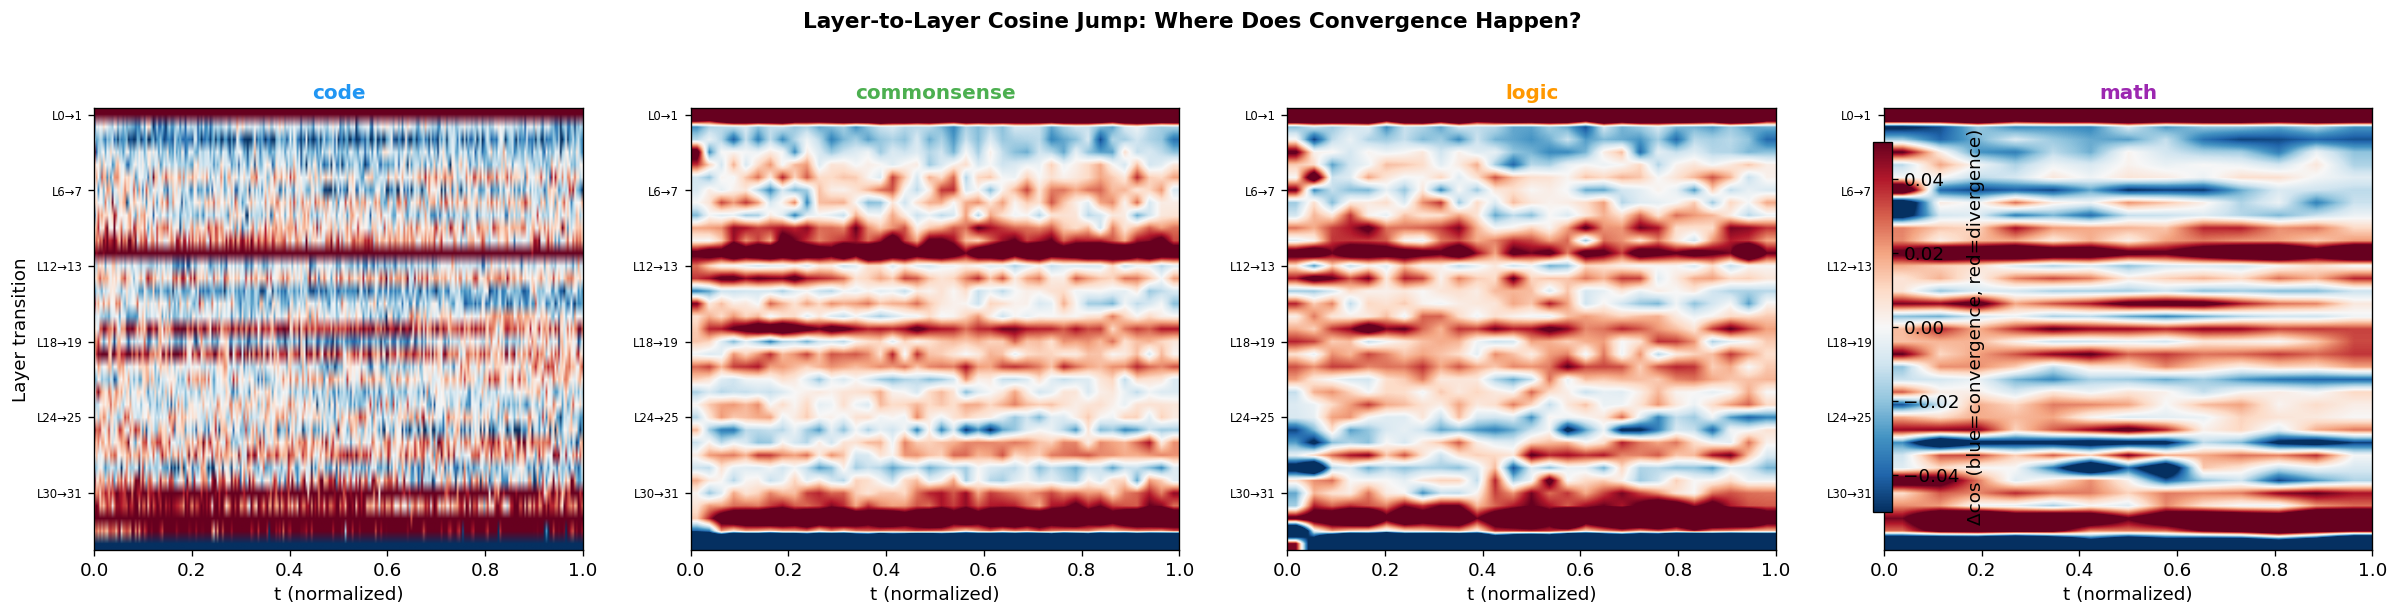

In [17]:
fig, axes = plt.subplots(1, len(domains_traj), figsize=(5 * len(domains_traj), 5))

for ax, domain in zip(axes, domains_traj):
    domain_results = [r for r in traj_results if r["domain"] == domain]
    jump_matrix = []
    for r in domain_results:
        min_tok = min(len(r["layers"][str(li)]["cosines"]) for li in all_layers_sorted)
        if min_tok < 2:
            continue
        cos_by_layer = np.array([r["layers"][str(li)]["cosines"][:min_tok] for li in all_layers_sorted])
        jumps = np.diff(cos_by_layer, axis=0)
        jump_matrix.append(jumps)
    if not jump_matrix:
        ax.set_title(f"{domain}: no data")
        continue
    min_t_all = min(j.shape[1] for j in jump_matrix)
    avg_jumps = np.mean([j[:, :min_t_all] for j in jump_matrix], axis=0)

    im = ax.imshow(avg_jumps, aspect="auto", cmap="RdBu_r", vmin=-0.05, vmax=0.05,
                   extent=[0, 1, len(all_layers_sorted) - 1.5, -0.5], interpolation="bilinear")
    tick_pos = list(range(0, len(all_layers_sorted) - 1, 6))
    ax.set_yticks(tick_pos)
    ax.set_yticklabels([f"L{all_layers_sorted[i]}→{all_layers_sorted[i+1]}" for i in tick_pos], fontsize=7)
    ax.set_xlabel("t (normalized)")
    ax.set_title(f"{domain}", fontsize=12, fontweight="bold", color=DC[domain])

axes[0].set_ylabel("Layer transition")
fig.suptitle("Layer-to-Layer Cosine Jump: Where Does Convergence Happen?", fontsize=13, fontweight="bold", y=1.02)
cbar = fig.colorbar(ScalarMappable(norm=Normalize(-0.05, 0.05), cmap="RdBu_r"),
                    ax=axes, shrink=0.8, label="Δcos (blue=convergence, red=divergence)")
plt.tight_layout()
plt.savefig("output/fig_layer_jumps.png", dpi=200, bbox_inches="tight")
plt.show()

### 8g. Deep Dive: Single Problem (Dijkstra)
Full layer × token heatmap + L18 cosine trace + ZH/EN norm overlay.
The chart a trader would stare at — three synchronized time series on one problem.

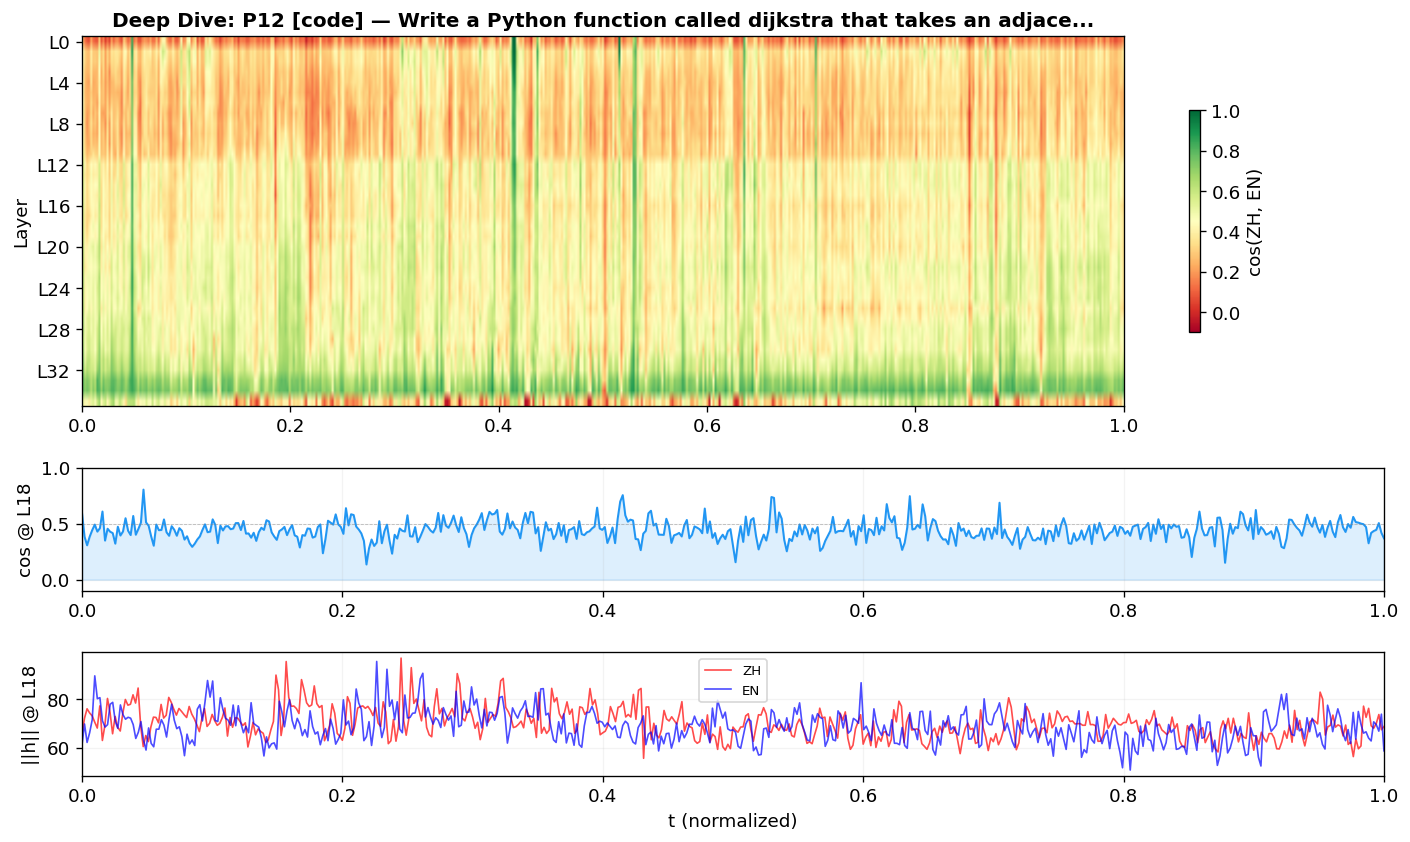

In [18]:
# Find Dijkstra or best code problem
dijk = [r for r in traj_results if "dijkstra" in r.get("problem_en", "").lower()]
if not dijk:
    dijk = [r for r in traj_results if r["domain"] == "code"]
target = dijk[0] if dijk else traj_results[-1]

t_all_layers = sorted(int(k) for k in target["layers"].keys())
max_t = max(len(target["layers"][str(li)]["cosines"]) for li in t_all_layers)

heatmap = np.full((len(t_all_layers), max_t), np.nan)
for yi, li in enumerate(t_all_layers):
    cos = target["layers"][str(li)]["cosines"]
    heatmap[yi, :len(cos)] = cos

fig = plt.figure(figsize=(14, 8))
gs = fig.add_gridspec(3, 1, height_ratios=[3, 1, 1], hspace=0.3)

ax1 = fig.add_subplot(gs[0])
im = ax1.imshow(heatmap, aspect="auto", cmap="RdYlGn", vmin=-0.1, vmax=1.0,
                extent=[0, 1, len(t_all_layers) - 0.5, -0.5], interpolation="bilinear")
ax1.set_ylabel("Layer")
tick_pos = list(range(0, len(t_all_layers), 4))
ax1.set_yticks(tick_pos)
ax1.set_yticklabels([f"L{t_all_layers[i]}" for i in tick_pos])
fig.colorbar(im, ax=ax1, shrink=0.6, label="cos(ZH, EN)")
ax1.set_title(f"Deep Dive: P{target['problem_idx']} [{target['domain']}] — {target['problem_en'][:60]}...",
              fontsize=12, fontweight="bold")

ax2 = fig.add_subplot(gs[1], sharex=ax1)
cos18 = target["layers"]["18"]["cosines"]
t18 = np.linspace(0, 1, len(cos18))
ax2.plot(t18, cos18, color="#2196F3", linewidth=1.2)
ax2.fill_between(t18, cos18, alpha=0.15, color="#2196F3")
ax2.set_ylabel("cos @ L18")
ax2.set_ylim(-0.1, 1.0)
ax2.axhline(0.5, color="gray", linewidth=0.5, linestyle="--", alpha=0.5)
ax2.grid(True, alpha=0.15)

ax3 = fig.add_subplot(gs[2], sharex=ax1)
zh_n = target["layers"]["18"]["zh_norms"]
en_n = target["layers"]["18"]["en_norms"]
t_zh = np.linspace(0, 1, len(zh_n))
t_en = np.linspace(0, 1, len(en_n))
ax3.plot(t_zh, zh_n, color="red", alpha=0.7, linewidth=1, label="ZH")
ax3.plot(t_en, en_n, color="blue", alpha=0.7, linewidth=1, label="EN")
ax3.set_ylabel("||h|| @ L18")
ax3.set_xlabel("t (normalized)")
ax3.legend(fontsize=8)
ax3.grid(True, alpha=0.15)

plt.savefig("output/fig_deep_dive.png", dpi=200, bbox_inches="tight")
plt.show()

### 8h. Norm Tracking + Cosine at L18 (Convergence Zone)
Top row: ZH (red) and EN (blue) hidden state norms overlaid on same normalized time axis.
Bottom row: cosine between them. One column per domain, using the problem with the most tokens.
If f is shared, norms should track each other regardless of language.

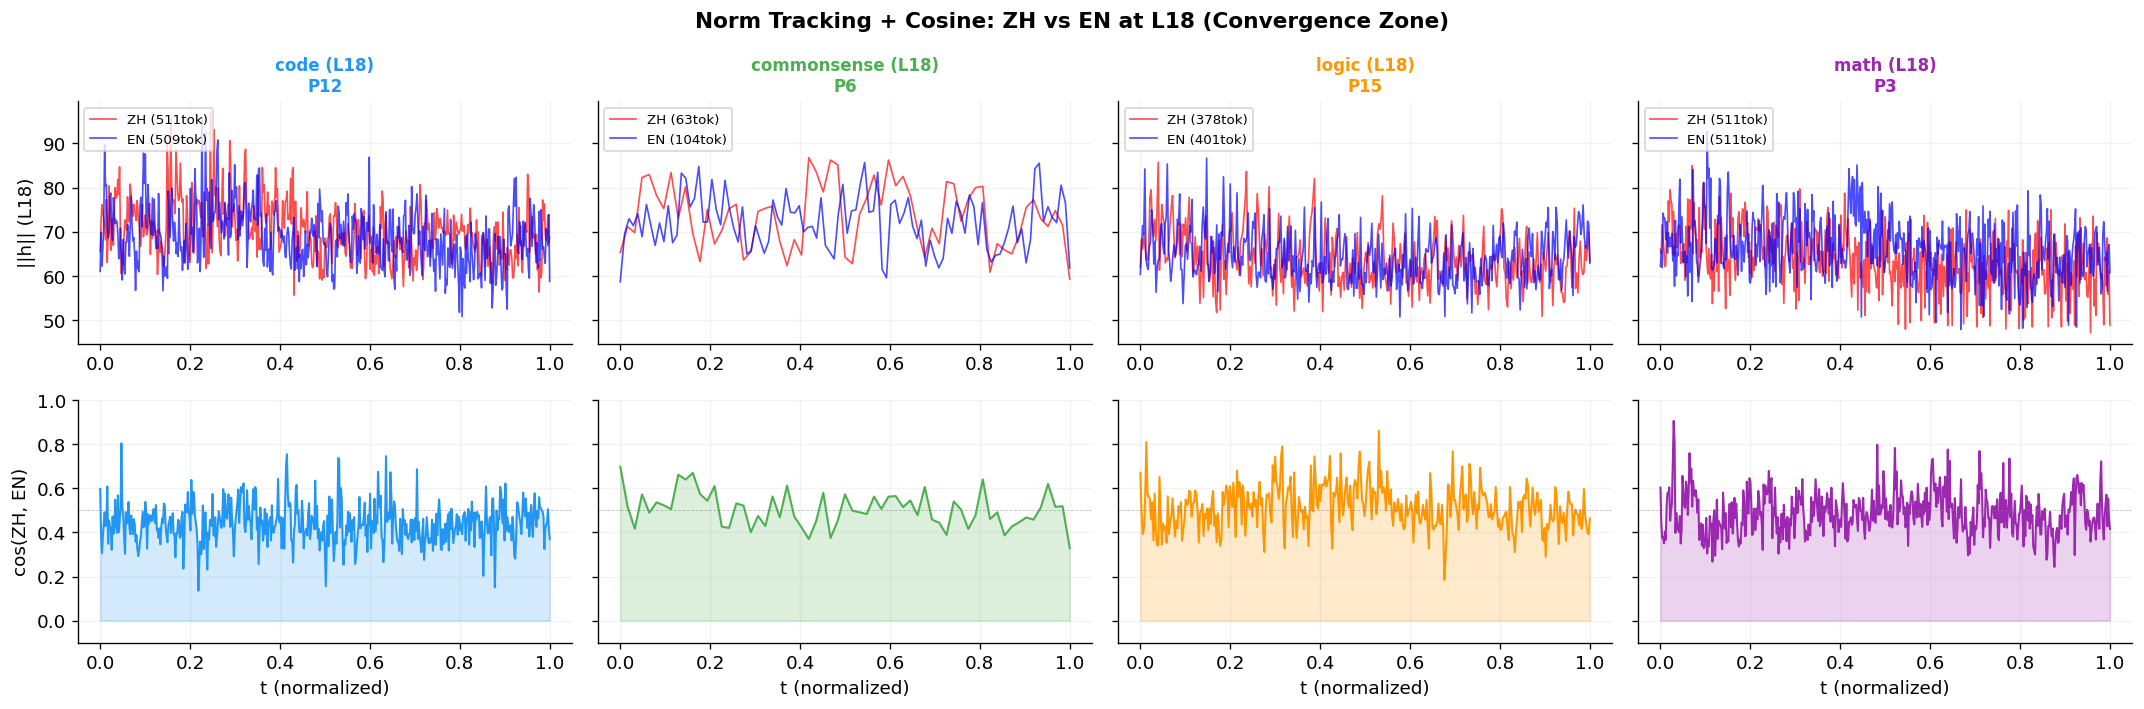

In [19]:
# Pick the problem with most tokens per domain (more data = better plot)
reps = {}
for r in traj_results:
    d = r["domain"]
    if d not in reps or min(r["zh_ntok"], r["en_ntok"]) > min(reps[d]["zh_ntok"], reps[d]["en_ntok"]):
        reps[d] = r

rep_domains = sorted(reps.keys())
fig, axes = plt.subplots(2, len(rep_domains), figsize=(4.5 * len(rep_domains), 6), sharey="row")

for col, domain in enumerate(rep_domains):
    r = reps[domain]
    li = "18"
    zh_norms = np.array(r["layers"][li]["zh_norms"])
    en_norms = np.array(r["layers"][li]["en_norms"])
    cos = np.array(r["layers"][li]["cosines"])
    t_zh = np.linspace(0, 1, len(zh_norms))
    t_en = np.linspace(0, 1, len(en_norms))
    t_cos = np.linspace(0, 1, len(cos))

    ax = axes[0][col]
    ax.plot(t_zh, zh_norms, color="red", alpha=0.7, linewidth=1, label=f"ZH ({len(zh_norms)}tok)")
    ax.plot(t_en, en_norms, color="blue", alpha=0.7, linewidth=1, label=f"EN ({len(en_norms)}tok)")
    ax.set_title(f"{domain} (L18)\nP{r['problem_idx']}", fontsize=10, fontweight="bold", color=DC[domain])
    ax.legend(fontsize=8, loc="upper left")
    ax.grid(True, alpha=0.15)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax2 = axes[1][col]
    ax2.plot(t_cos, cos, color=DC[domain], linewidth=1.2)
    ax2.fill_between(t_cos, cos, alpha=0.2, color=DC[domain])
    ax2.set_ylim(-0.1, 1.0)
    ax2.set_xlabel("t (normalized)")
    ax2.axhline(0.5, color="gray", linewidth=0.5, linestyle="--", alpha=0.5)
    ax2.grid(True, alpha=0.15)
    ax2.spines["top"].set_visible(False)
    ax2.spines["right"].set_visible(False)

axes[0][0].set_ylabel("||h|| (L18)")
axes[1][0].set_ylabel("cos(ZH, EN)")
fig.suptitle("Norm Tracking + Cosine: ZH vs EN at L18 (Convergence Zone)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("output/fig_norm_vs_cosine_L18.png", dpi=200, bbox_inches="tight")
plt.show()